<a href="https://colab.research.google.com/github/helenakkr/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCD Assignment 02 - Image Enhancement

Pada assignment ini dilakukan implementasi image enhancement terhadap tiga jenis permasalahan citra, yaitu low-contrast image, blurred image, dan dark image.

Setiap permasalahan ditangani menggunakan metode enhancement yang berbeda sesuai dengan karakteristik citra:

1. Low-Contrast Image menggunakan Contrast Limited Adaptive Histogram Equalization (CLAHE).
2. Blurred Image menggunakan Unsharp Masking.
3. Dark Image menggunakan Gamma Correction.

Seluruh citra yang digunakan berasal dari sample image pada library Scikit-Image (`skimage.data`).

## 1. Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

from skimage import data, exposure, filters, img_as_float, img_as_ubyte, io

## 2. Low-Contrast Image Enhancement Using CLAHE

Pada bagian pertama dilakukan enhancement terhadap citra yang memiliki kontras relatif rendah.

Citra yang digunakan adalah `moon()` dari Scikit-Image. Metode Contrast Limited Adaptive Histogram Equalization (CLAHE) digunakan karena mampu meningkatkan kontras secara lokal dan membatasi peningkatan kontras yang berlebihan menggunakan parameter `clip_limit`.

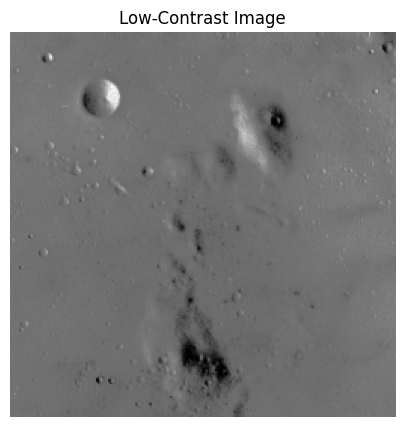

In [2]:
low_contrast_image = img_as_float(data.moon())

plt.figure(figsize=(7, 5))
plt.imshow(low_contrast_image, cmap="gray")
plt.title("Low-Contrast Image")
plt.axis("off")
plt.show()

### Histogram Before Enhancement

Histogram digunakan untuk melihat distribusi intensitas piksel pada citra sebelum dilakukan enhancement.

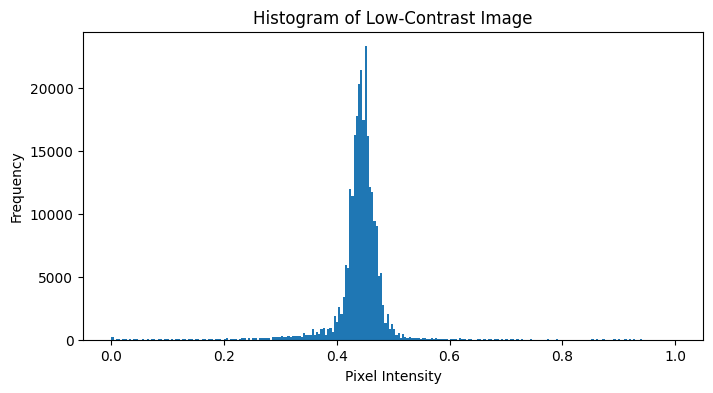

In [3]:
plt.figure(figsize=(8, 4))

plt.hist(low_contrast_image.ravel(), bins=256)

plt.title("Histogram of Low-Contrast Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.show()

### Apply CLAHE

CLAHE meningkatkan kontras pada area-area lokal di dalam citra. Parameter `clip_limit` digunakan untuk membatasi peningkatan histogram sehingga kontras tidak ditingkatkan secara berlebihan.

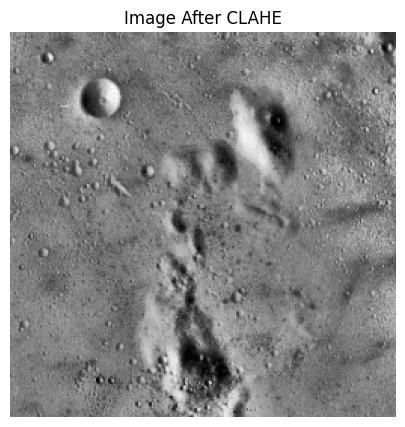

In [4]:
clahe_image = exposure.equalize_adapthist(
    low_contrast_image,
    clip_limit=0.03
)

plt.figure(figsize=(7, 5))
plt.imshow(clahe_image, cmap="gray")
plt.title("Image After CLAHE")
plt.axis("off")
plt.show()

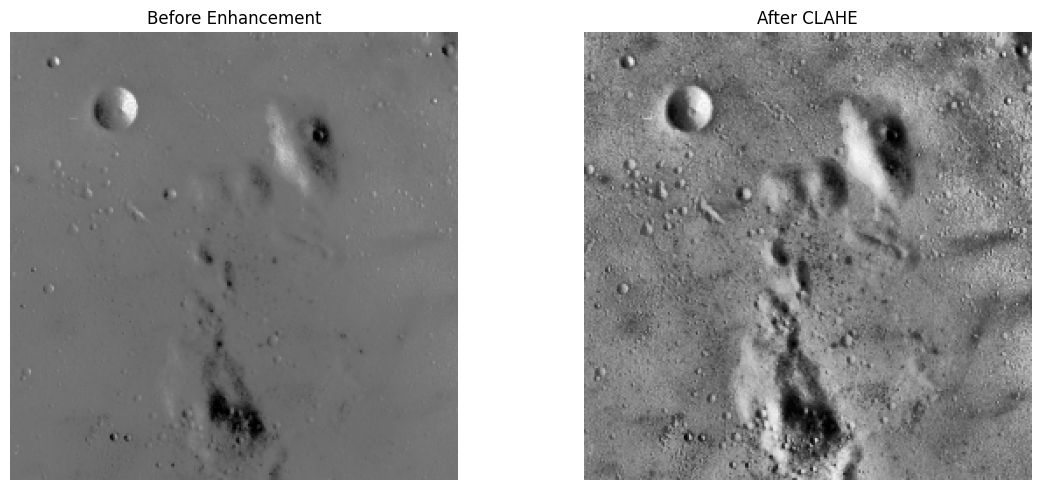

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(low_contrast_image, cmap="gray")
axes[0].set_title("Before Enhancement")
axes[0].axis("off")

axes[1].imshow(clahe_image, cmap="gray")
axes[1].set_title("After CLAHE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

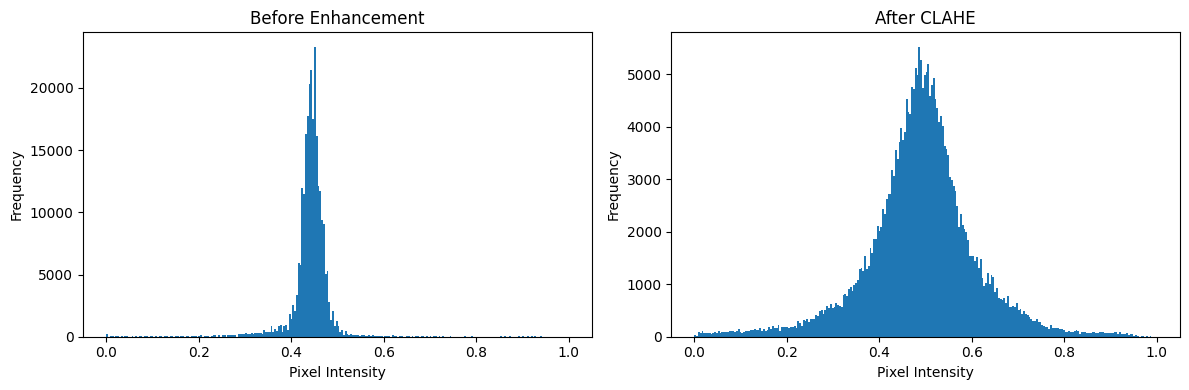

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(low_contrast_image.ravel(), bins=256)
axes[0].set_title("Before Enhancement")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")

axes[1].hist(clahe_image.ravel(), bins=256)
axes[1].set_title("After CLAHE")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Contrast Measurement

Standar deviasi intensitas piksel digunakan sebagai ukuran sederhana untuk melihat penyebaran nilai intensitas. Nilai standar deviasi yang lebih besar menunjukkan variasi intensitas yang lebih besar.

In [7]:
contrast_before = np.std(low_contrast_image)
contrast_after = np.std(clahe_image)

print(f"Contrast Before CLAHE : {contrast_before:.4f}")
print(f"Contrast After CLAHE  : {contrast_after:.4f}")

Contrast Before CLAHE : 0.0523
Contrast After CLAHE  : 0.1195


## 3. Blurred Image Enhancement Using Unsharp Masking

Pada bagian kedua dilakukan enhancement terhadap blurred image.

Citra `camera()` digunakan sebagai citra awal. Gaussian Blur diterapkan untuk menghasilkan blurred image. Selanjutnya, metode Unsharp Masking digunakan untuk meningkatkan kembali ketajaman tepi dan detail pada citra.

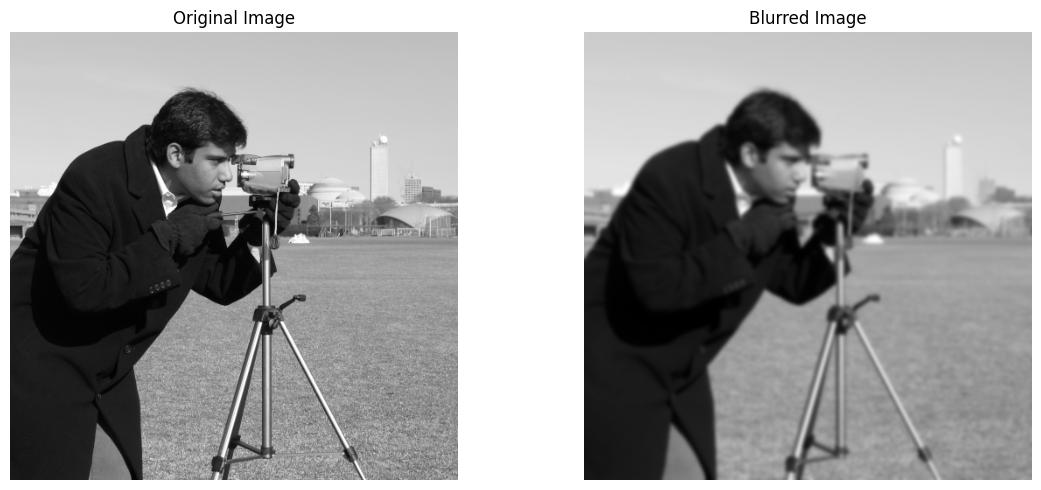

In [8]:
original_blur_image = img_as_float(data.camera())

blurred_image = filters.gaussian(
    original_blur_image,
    sigma=2
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_blur_image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(blurred_image, cmap="gray")
axes[1].set_title("Blurred Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Apply Unsharp Masking

Unsharp Masking digunakan untuk mempertajam citra dengan meningkatkan perbedaan intensitas pada bagian tepi objek.

Parameter `radius` menentukan area yang digunakan dalam proses sharpening, sedangkan `amount` menentukan kekuatan efek sharpening.

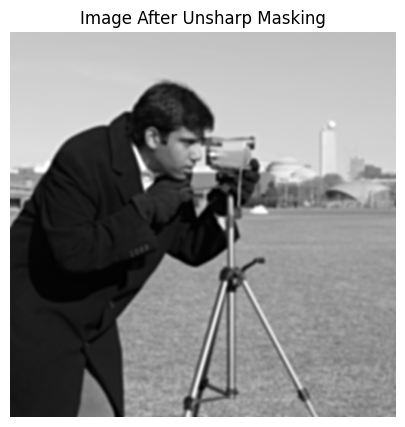

In [9]:
sharpened_image = filters.unsharp_mask(
    blurred_image,
    radius=2,
    amount=1.5
)

plt.figure(figsize=(7, 5))
plt.imshow(sharpened_image, cmap="gray")
plt.title("Image After Unsharp Masking")
plt.axis("off")
plt.show()

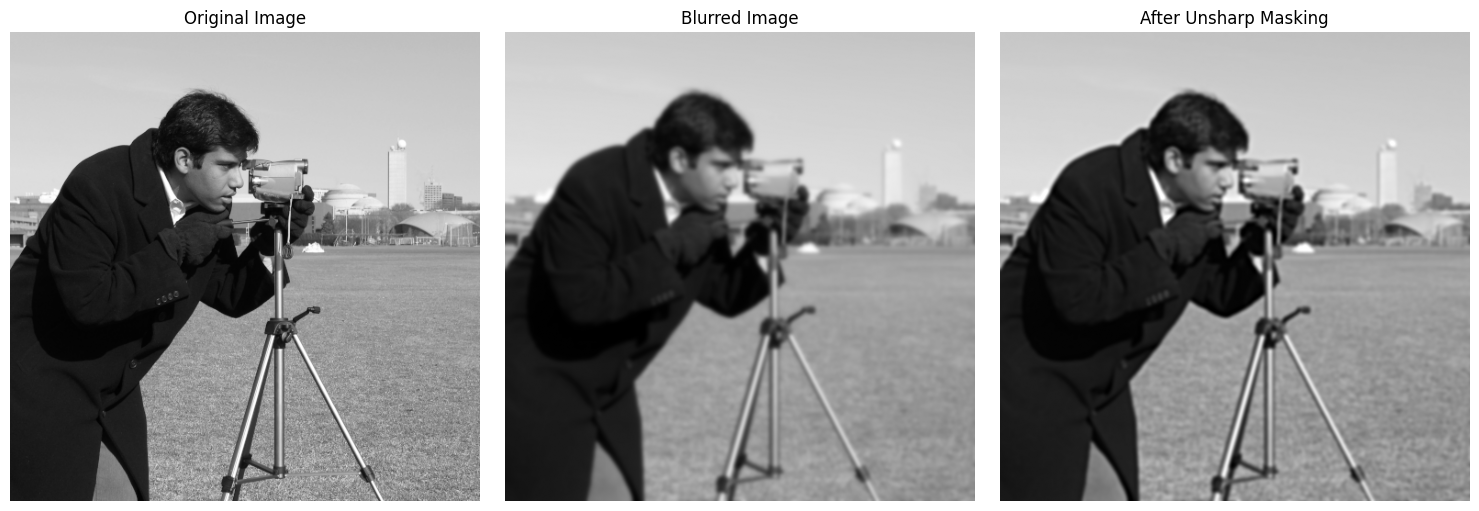

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_blur_image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(blurred_image, cmap="gray")
axes[1].set_title("Blurred Image")
axes[1].axis("off")

axes[2].imshow(sharpened_image, cmap="gray")
axes[2].set_title("After Unsharp Masking")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Sharpness Measurement

Ketajaman citra diukur menggunakan rata-rata magnitude dari Sobel edge detector. Nilai yang lebih tinggi menunjukkan bahwa perubahan intensitas pada bagian tepi citra lebih kuat, sehingga citra memiliki tingkat ketajaman yang lebih tinggi.

In [16]:
blurred_sharpness = np.mean(filters.sobel(blurred_image))
enhanced_sharpness = np.mean(filters.sobel(sharpened_image))

print(f"Blurred Image Sharpness  : {blurred_sharpness:.4f}")
print(f"Enhanced Image Sharpness : {enhanced_sharpness:.4f}")

Blurred Image Sharpness  : 0.0141
Enhanced Image Sharpness : 0.0200


## 4. Dark Image Enhancement Using Gamma Correction

Pada bagian ketiga dilakukan enhancement terhadap dark image.

Citra `coins()` digunakan sebagai citra awal. Intensitas citra dikurangi untuk menghasilkan citra yang lebih gelap. Selanjutnya, Gamma Correction digunakan untuk meningkatkan tingkat kecerahan sehingga detail pada area gelap menjadi lebih mudah diamati.

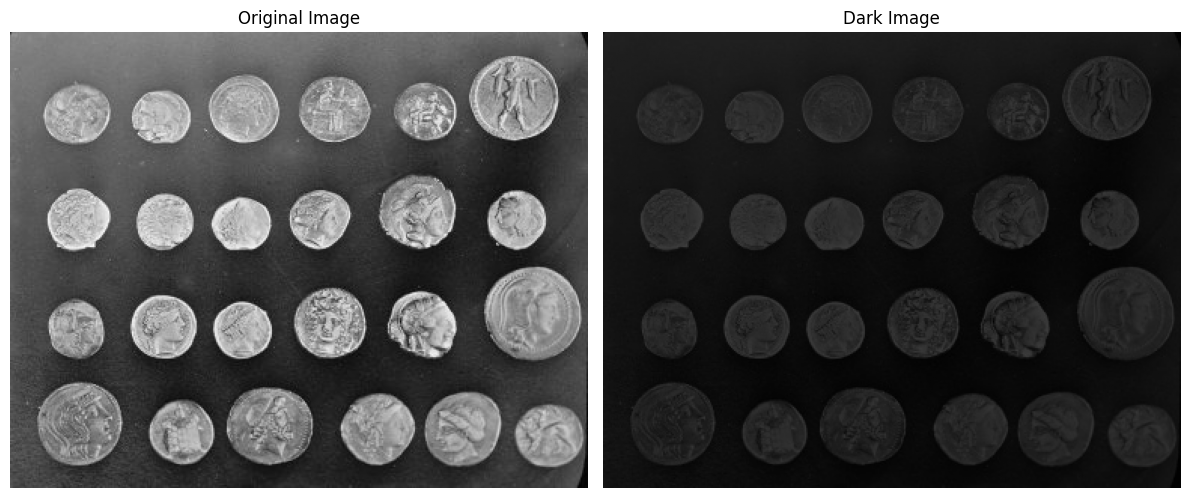

In [11]:
original_dark_image = img_as_float(data.coins())

dark_image = original_dark_image * 0.25

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(original_dark_image, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(dark_image, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Dark Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Apply Gamma Correction

Gamma Correction digunakan untuk mengubah tingkat kecerahan citra secara non-linear.

Nilai gamma kurang dari 1 digunakan untuk meningkatkan kecerahan citra gelap. Pada implementasi ini digunakan nilai gamma sebesar 0.5.

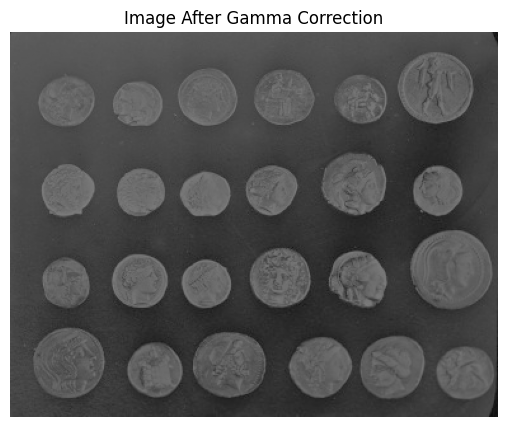

In [12]:
gamma_image = exposure.adjust_gamma(
    dark_image,
    gamma=0.5
)

plt.figure(figsize=(7, 5))
plt.imshow(gamma_image, cmap="gray", vmin=0, vmax=1)
plt.title("Image After Gamma Correction")
plt.axis("off")
plt.show()

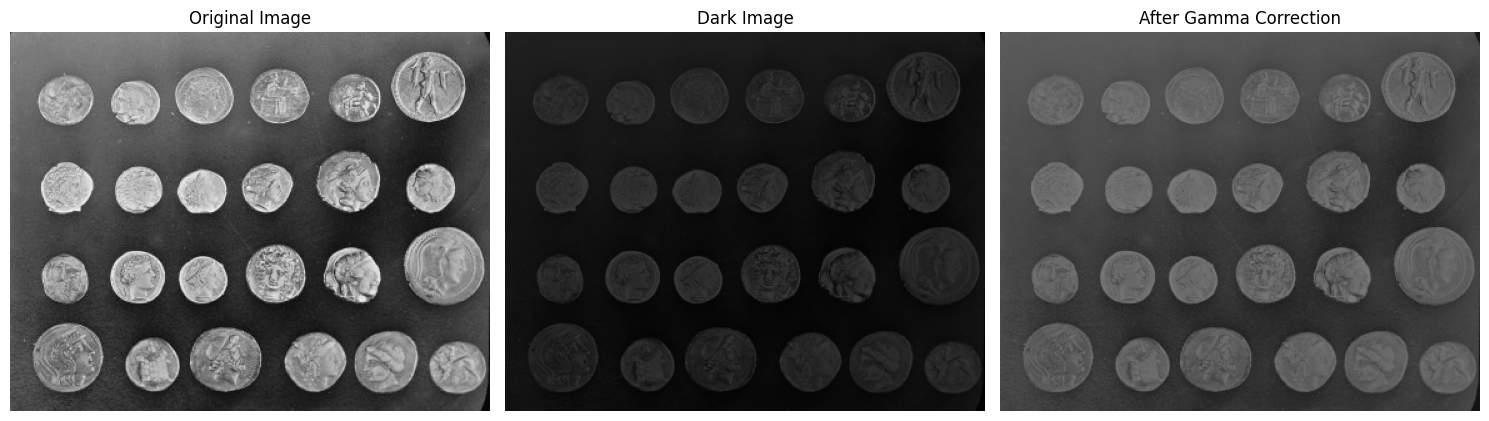

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_dark_image, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(dark_image, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Dark Image")
axes[1].axis("off")

axes[2].imshow(gamma_image, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("After Gamma Correction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Brightness Measurement

Nilai rata-rata intensitas piksel digunakan untuk melihat perubahan tingkat kecerahan citra sebelum dan sesudah Gamma Correction.

In [14]:
brightness_dark = np.mean(dark_image)
brightness_enhanced = np.mean(gamma_image)

print(f"Dark Image Mean Intensity     : {brightness_dark:.4f}")
print(f"Enhanced Image Mean Intensity : {brightness_enhanced:.4f}")

Dark Image Mean Intensity     : 0.0950
Enhanced Image Mean Intensity : 0.2961


## 5. Final Comparison

Bagian berikut menampilkan perbandingan hasil image enhancement dari ketiga permasalahan citra yang telah diuji.

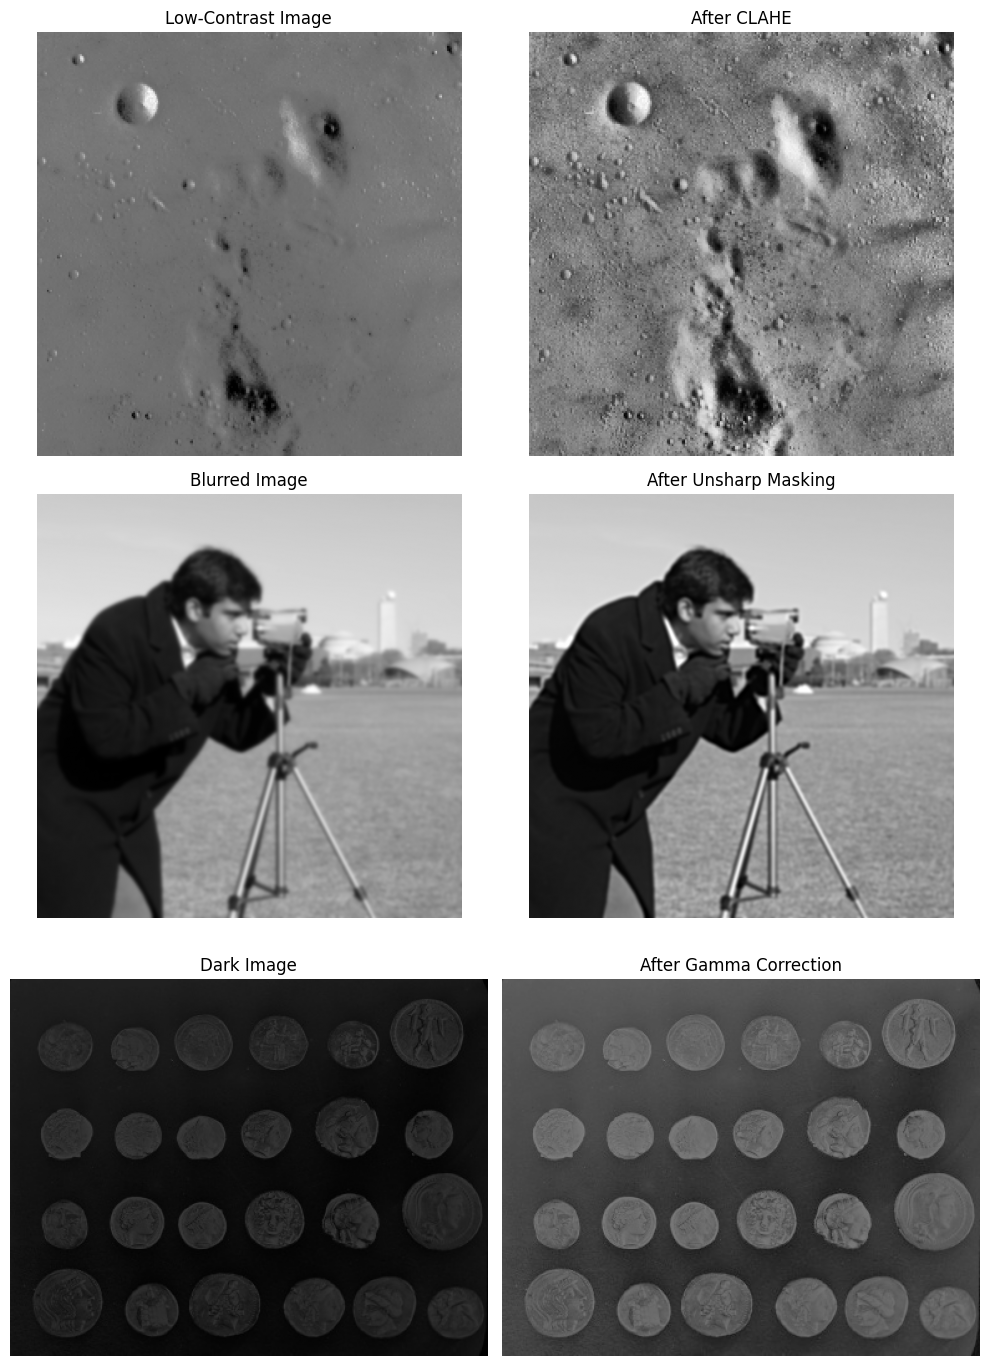

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

axes[0, 0].imshow(low_contrast_image, cmap="gray")
axes[0, 0].set_title("Low-Contrast Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(clahe_image, cmap="gray")
axes[0, 1].set_title("After CLAHE")
axes[0, 1].axis("off")

axes[1, 0].imshow(blurred_image, cmap="gray")
axes[1, 0].set_title("Blurred Image")
axes[1, 0].axis("off")

axes[1, 1].imshow(sharpened_image, cmap="gray")
axes[1, 1].set_title("After Unsharp Masking")
axes[1, 1].axis("off")

axes[2, 0].imshow(dark_image, cmap="gray", vmin=0, vmax=1)
axes[2, 0].set_title("Dark Image")
axes[2, 0].axis("off")

axes[2, 1].imshow(gamma_image, cmap="gray", vmin=0, vmax=1)
axes[2, 1].set_title("After Gamma Correction")
axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

## 6. Analysis

Pada assignment ini dilakukan image enhancement terhadap tiga jenis permasalahan citra, yaitu low-contrast image, blurred image, dan dark image. Setiap jenis citra ditangani menggunakan metode yang berbeda sesuai dengan karakteristik permasalahannya.

### Low-Contrast Image

Pada citra `moon()`, detail permukaan pada citra awal terlihat relatif samar karena perbedaan intensitas antarbagian citra cukup kecil. Setelah dilakukan enhancement menggunakan CLAHE, tekstur permukaan dan beberapa detail kecil menjadi lebih mudah diamati. Distribusi intensitas piksel juga menjadi lebih luas dibandingkan sebelum enhancement.

Hasil pengukuran menunjukkan bahwa nilai standar deviasi intensitas meningkat dari **0.0523** menjadi **0.1195**. Peningkatan tersebut menunjukkan bahwa variasi intensitas piksel setelah CLAHE menjadi lebih besar. Hal ini sesuai dengan hasil visual, di mana perbedaan antara area gelap dan terang menjadi lebih jelas. Dengan demikian, CLAHE berhasil meningkatkan kontras lokal pada citra.

### Blurred Image

Pada percobaan kedua, citra `camera()` terlebih dahulu diberi Gaussian Blur sehingga detail dan tepi objek menjadi lebih halus. Efek blur terlihat terutama pada bagian wajah, kamera, pakaian, tripod, dan objek di latar belakang.

Setelah Unsharp Masking diterapkan, tepi objek terlihat lebih tegas dibandingkan blurred image. Beberapa detail yang sebelumnya terlihat lembut menjadi lebih jelas, terutama pada bagian kamera, wajah, pakaian, dan tripod.

Hasil pengukuran ketajaman menggunakan rata-rata magnitude Sobel menunjukkan peningkatan dari **0.0141** pada blurred image menjadi **0.0200** setelah enhancement. Peningkatan ini menunjukkan bahwa respons edge pada citra menjadi lebih kuat setelah Unsharp Masking diterapkan.

Meskipun demikian, Unsharp Masking tidak sepenuhnya mengembalikan informasi yang telah hilang akibat proses blur. Metode ini terutama meningkatkan ketegasan tepi dan detail yang masih tersedia pada citra.

### Dark Image

Pada percobaan ketiga, citra `coins()` dibuat lebih gelap dengan mengurangi nilai intensitas piksel menjadi 25% dari citra awal. Akibatnya, sebagian besar detail pada koin menjadi sulit diamati karena nilai intensitas berada pada tingkat yang rendah.

Gamma Correction dengan nilai gamma 0.5 kemudian diterapkan untuk meningkatkan brightness. Setelah enhancement, objek koin dan detail permukaannya menjadi jauh lebih mudah diamati.

Hasil pengukuran menunjukkan bahwa rata-rata intensitas citra meningkat dari **0.0950** menjadi **0.2961**. Peningkatan nilai tersebut menunjukkan bahwa Gamma Correction berhasil meningkatkan brightness citra secara signifikan tanpa hanya melakukan penambahan intensitas secara linear.

Secara keseluruhan, ketiga metode berhasil memperbaiki karakteristik citra sesuai dengan permasalahan masing-masing. CLAHE efektif untuk meningkatkan kontras lokal, Unsharp Masking meningkatkan ketajaman tepi pada blurred image, sedangkan Gamma Correction efektif untuk meningkatkan kecerahan pada dark image.

## 7. Conclusion

Berdasarkan implementasi yang telah dilakukan, metode image enhancement perlu dipilih sesuai dengan jenis permasalahan pada citra.

CLAHE berhasil meningkatkan kontras pada low-contrast image, yang ditunjukkan oleh peningkatan standar deviasi intensitas dari **0.0523** menjadi **0.1195** serta detail citra yang menjadi lebih jelas.

Unsharp Masking mampu meningkatkan ketajaman blurred image, yang ditunjukkan oleh peningkatan nilai sharpness dari **0.0141** menjadi **0.0200**. Hasil tersebut menunjukkan bahwa tepi dan detail citra menjadi lebih tegas setelah proses enhancement.

Gamma Correction berhasil meningkatkan brightness dark image, dengan nilai rata-rata intensitas meningkat dari **0.0950** menjadi **0.2961**. Setelah enhancement, detail objek yang sebelumnya sulit diamati menjadi lebih terlihat.

Dengan demikian, CLAHE, Unsharp Masking, dan Gamma Correction dapat digunakan sebagai metode image enhancement yang efektif apabila diterapkan pada jenis degradasi citra yang sesuai.

In [17]:
os.makedirs("images", exist_ok=True)

io.imsave(
    "images/low_contrast.jpg",
    img_as_ubyte(low_contrast_image)
)

io.imsave(
    "images/low_contrast_enhanced.jpg",
    img_as_ubyte(clahe_image)
)

io.imsave(
    "images/blurred.jpg",
    img_as_ubyte(blurred_image)
)

io.imsave(
    "images/blurred_enhanced.jpg",
    img_as_ubyte(sharpened_image)
)

io.imsave(
    "images/dark.jpg",
    img_as_ubyte(dark_image)
)

io.imsave(
    "images/dark_enhanced.jpg",
    img_as_ubyte(gamma_image)
)

print("All images successfully saved.")

All images successfully saved.
